# Comparative Analysis of Dimension Reduction Methods

This notebook aggregates the results produced by the individual dimension reduction (DR) method
notebooks: PCA, Kernel PCA (RBF and Polynomial), Gaussian Random Projection (GRP), and Sparse
Random Projection (SRP) into a single comparative analysis.

For each method, the following results are combined across all evaluated numbers of retained
components (n_components = [5, 10, 25, 50]):

- Classification performance (Accuracy, Macro Precision, Macro Recall, Macro F1, Macro ROC AUC)
- Computational efficiency (fit time, transform time, process time, total runtime)
- Reconstruction error (MSE)

Representation quality is reported separately per method, since each method is evaluated using
a measure specific to its own properties (explained variance for PCA, silhouette score for KPCA,
pairwise distance correlation for GRP and SRP).

To assess whether observed differences in classification performance between methods are
statistically meaningful, pairwise Welch's t-tests (with Holm-Bonferroni correction for multiple
comparisons) are conducted on classification accuracy at each number of retained components.
Because identical cross-validation splits were used across all methods, these tests are computed
from summary statistics (mean, standard deviation, n=25) as a conservative approximation of a
paired comparison, since raw per-split values were not retained by the individual method
notebooks. Effect size (Cohen's d) is reported alongside p-values to distinguish statistically
significant differences from practically meaningful ones.

## Workflow

1. Load the saved classification, reconstruction, and runtime summaries for each method.
2. Combine classification results into a single long-format table; compare methods across
   n_components for each classification metric.
3. Combine runtime results, merging per-method process-time columns into a single shared
   column; compare fit time (log and linear scale), transform time, process time, and total
   runtime.
4. Combine reconstruction error results; compare with an explicit interpretive caveat.
5. Load and present representation quality results separately per method.
6. Conduct pairwise statistical comparisons of classification accuracy across methods, with
   multiple-comparison correction and effect size reporting.
7. Identify best-performing configuration per method.
8. Save combined summary tables and statistical test results.

## 1. Initial Configurations

In [1]:
# imports and paths
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind_from_stats
from itertools import combinations

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

metrics_dir = Path("../results/metrics")
timings_dir = Path("../results/timings")
comparison_fig_dir = Path("../figures/Comparison")
comparison_fig_dir.mkdir(parents=True, exist_ok=True)

n_components_list = [5, 10, 25, 50]

In [2]:
# Define Loader functions

def load_classification_summary(path, method_name):
    df = pd.read_csv(path, index_col=[0, 1])
    df = df.reset_index()
    df.columns = ["n_components", "Metric", "Mean", "Std"]

    if (df["Metric"] == "Split").any():
        print(f"WARNING: 'Split' row found in {method_name} ({path.name}) — "
              f"removing it now, but verify the source notebook was actually re-run after the fix.")
        df = df[df["Metric"] != "Split"].reset_index(drop=True)

    df["Method"] = method_name
    return df


def load_reconstruction_summary(path, method_name):
    df = pd.read_csv(path, index_col=[0, 1])
    df = df.reset_index()
    df.columns = ["n_components", "Metric", "Mean", "Std"]
    df["Method"] = method_name
    return df


def load_runtime_summary(path, method_name):
    df = pd.read_csv(path, index_col=0)
    df.index.name = "n_components"
    df = df.reset_index()
    df["Method"] = method_name
    return df

## 2. Load and combine results

In [3]:
# Classification Results

classification_sources = {
    "PCA": metrics_dir / "PCA_classification_summary.csv",
    "GRP": metrics_dir / "grp_classification_summary.csv",
    "SRP": metrics_dir / "srp_classification_summary.csv",
    "KPCA (RBF)": metrics_dir / "KPCA_RBF_classification_summary.csv",
    "KPCA (Polynomial)": metrics_dir / "KPCA_Polynomial_classification_summary.csv",
}

classification_frames = []
for method_name, path in classification_sources.items():
    if not path.exists():
        print(f"MISSING FILE for {method_name}: {path}")
        continue
    classification_frames.append(load_classification_summary(path, method_name))

master_classification = pd.concat(classification_frames, ignore_index=True)
master_classification.to_csv(metrics_dir / "combined_classification_summary.csv", index=False)
display(master_classification)

,n_components,Metric,Mean,Std,Method
0,5,Accuracy,0.983762,0.010050,PCA
1,5,Macro Precision,0.981497,0.011348,PCA
2,5,Macro Recall,0.981513,0.012935,PCA
3,5,Macro F1,0.981118,0.012082,PCA
4,5,Macro ROC AUC,0.999017,0.001243,PCA
...,...,...,...,...,...
95,50,Accuracy,0.996502,0.005727,KPCA (Polynomial)
96,50,Macro Precision,0.997428,0.004330,KPCA (Polynomial)
97,50,Macro Recall,0.994433,0.009540,KPCA (Polynomial)
98,50,Macro F1,0.995810,0.007156,KPCA (Polynomial)


In [4]:
# Reconstruction Results

reconstruction_sources = {
    "PCA": metrics_dir / "PCA_reconstruction_summary.csv",
    "GRP": metrics_dir / "grp_reconstruction_summary.csv",
    "SRP": metrics_dir / "srp_reconstruction_summary.csv",
    "KPCA (RBF)": metrics_dir / "KPCA_RBF_reconstruction_summary.csv",
    "KPCA (Polynomial)": metrics_dir / "KPCA_Polynomial_reconstruction_summary.csv",
}

reconstruction_frames = []
for method_name, path in reconstruction_sources.items():
    if not path.exists():
        print(f"MISSING FILE for {method_name}: {path}")
        continue
    reconstruction_frames.append(load_reconstruction_summary(path, method_name))

master_reconstruction = pd.concat(reconstruction_frames, ignore_index=True)
master_reconstruction.to_csv(metrics_dir / "combined_reconstruction_summary.csv", index=False)
display(master_reconstruction)

,n_components,Metric,Mean,Std,Method
0,5,Reconstruction MSE,1.002959,0.027665,PCA
1,10,Reconstruction MSE,0.840197,0.022255,PCA
2,25,Reconstruction MSE,0.726573,0.019042,PCA
3,50,Reconstruction MSE,0.661861,0.017601,PCA
4,5,Reconstruction MSE,1.787700,0.025375,GRP
5,10,Reconstruction MSE,1.787501,0.025394,GRP
6,25,Reconstruction MSE,1.786514,0.025411,GRP
7,50,Reconstruction MSE,1.783980,0.025427,GRP
8,5,Reconstruction MSE,1.787953,0.025394,SRP
9,10,Reconstruction MSE,1.787160,0.025367,SRP


In [5]:
# Runtime Results

runtime_sources = {
    "PCA": timings_dir / "PCA_runtime_summary.csv",
    "GRP": timings_dir / "grp_runtime_summary.csv",
    "SRP": timings_dir / "srp_runtime_summary.csv",
    "KPCA (RBF)": timings_dir / "KPCA_RBF_runtime_summary.csv",
    "KPCA (Polynomial)": timings_dir / "KPCA_Polynomial_runtime_summary.csv",
}

runtime_frames = []
for method_name, path in runtime_sources.items():
    if not path.exists():
        print(f"MISSING FILE for {method_name}: {path}")
        continue
    runtime_frames.append(load_runtime_summary(path, method_name))

master_runtime = pd.concat(runtime_frames, ignore_index=True)
master_runtime.to_csv(timings_dir / "combined_runtime_summary.csv", index=False)
display(master_runtime)

,n_components,Fit Time Mean (s),Fit Time Std (s),Transform Time Mean (s),Transform Time Std (s),PCA Process Time Mean (s),PCA Process Time Std (s),Total Runtime (s),Method,GRP Process Time Mean (s),GRP Process Time Std (s),SRP Process Time Mean (s),SRP Process Time Std (s),KPCA Process Time Mean (s),KPCA Process Time Std (s)
0,5,0.513217,0.022694,0.012753,0.003922,0.525970,0.023770,100.288369,PCA,NaN,NaN,NaN,NaN,NaN,NaN
1,10,0.539847,0.022452,0.013671,0.003900,0.553517,0.023876,95.569041,PCA,NaN,NaN,NaN,NaN,NaN,NaN
2,25,1.007973,0.101879,0.014115,0.002538,1.022088,0.101530,105.091197,PCA,NaN,NaN,NaN,NaN,NaN,NaN
3,50,1.529165,0.189167,0.017907,0.003537,1.547072,0.190449,117.496555,PCA,NaN,NaN,NaN,NaN,NaN,NaN
4,5,0.061567,0.013438,0.010191,0.001340,NaN,NaN,82.174042,GRP,0.071758,0.013543,NaN,NaN,NaN,NaN
5,10,0.064921,0.004885,0.010694,0.001080,NaN,NaN,90.279018,GRP,0.075614,0.005353,NaN,NaN,NaN,NaN
6,25,0.081648,0.005172,0.013374,0.002303,NaN,NaN,113.364848,GRP,0.095022,0.005563,NaN,NaN,NaN,NaN
7,50,0.114419,0.005138,0.015986,0.001262,NaN,NaN,94.970422,GRP,0.130405,0.005683,NaN,NaN,NaN,NaN
8,5,0.047886,0.005400,0.005752,0.000758,NaN,NaN,84.311880,SRP,NaN,NaN,0.053638,0.005858,NaN,NaN
9,10,0.055698,0.007055,0.006008,0.000716,NaN,NaN,88.119596,SRP,NaN,NaN,0.061705,0.007451,NaN,NaN


In [6]:
# Merge the per-method Process Time columns into one shared column
process_time_mean_cols = [c for c in master_runtime.columns if "Process Time Mean" in c]
process_time_std_cols = [c for c in master_runtime.columns if "Process Time Std" in c]

master_runtime["Process Time Mean (s)"] = master_runtime[process_time_mean_cols].bfill(axis=1).iloc[:, 0]
master_runtime["Process Time Std (s)"] = master_runtime[process_time_std_cols].bfill(axis=1).iloc[:, 0]

master_runtime = master_runtime.drop(columns=process_time_mean_cols + process_time_std_cols)
master_runtime.to_csv(timings_dir / "combined_runtime_summary.csv", index=False)
display(master_runtime)

,n_components,Fit Time Mean (s),Fit Time Std (s),Transform Time Mean (s),Transform Time Std (s),Total Runtime (s),Method,Process Time Mean (s),Process Time Std (s)
0,5,0.513217,0.022694,0.012753,0.003922,100.288369,PCA,0.525970,0.023770
1,10,0.539847,0.022452,0.013671,0.003900,95.569041,PCA,0.553517,0.023876
2,25,1.007973,0.101879,0.014115,0.002538,105.091197,PCA,1.022088,0.101530
3,50,1.529165,0.189167,0.017907,0.003537,117.496555,PCA,1.547072,0.190449
4,5,0.061567,0.013438,0.010191,0.001340,82.174042,GRP,0.071758,0.013543
5,10,0.064921,0.004885,0.010694,0.001080,90.279018,GRP,0.075614,0.005353
6,25,0.081648,0.005172,0.013374,0.002303,113.364848,GRP,0.095022,0.005563
7,50,0.114419,0.005138,0.015986,0.001262,94.970422,GRP,0.130405,0.005683
8,5,0.047886,0.005400,0.005752,0.000758,84.311880,SRP,0.053638,0.005858
9,10,0.055698,0.007055,0.006008,0.000716,88.119596,SRP,0.061705,0.007451


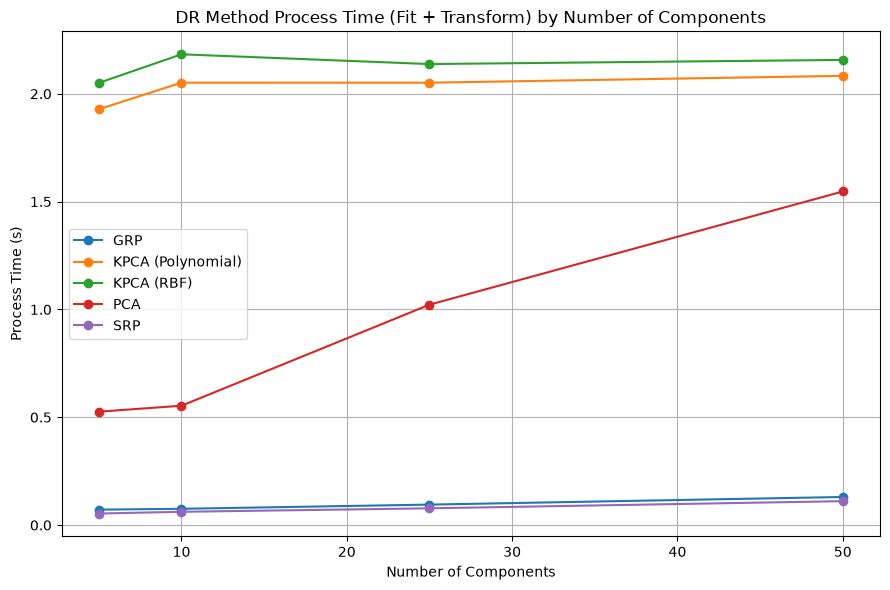

In [7]:
plt.figure(figsize=(9, 6))
for method_name, group in master_runtime.groupby("Method"):
    group = group.sort_values("n_components")
    plt.plot(group["n_components"], group["Process Time Mean (s)"], marker="o", label=method_name)
plt.xlabel("Number of Components")
plt.ylabel("Process Time (s)")
plt.title("DR Method Process Time (Fit + Transform) by Number of Components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(comparison_fig_dir / "comparison_process_time.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Classification Performance Comparison

The following plots compare each classification metric across all five DR configurations
(PCA, GRP, SRP, KPCA-RBF, KPCA-Polynomial) as a function of the number of retained
components. Error bars represent one standard deviation across the 25 cross-validation
splits.

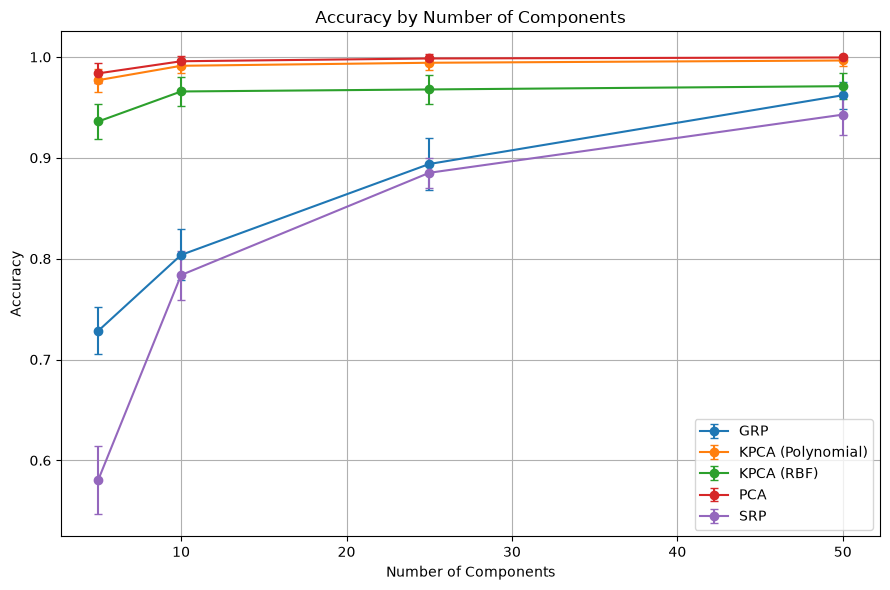

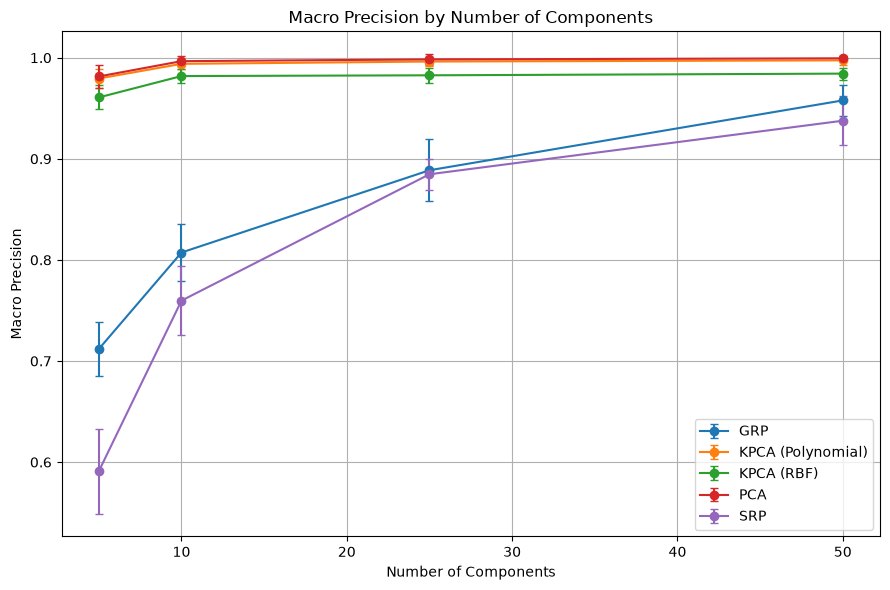

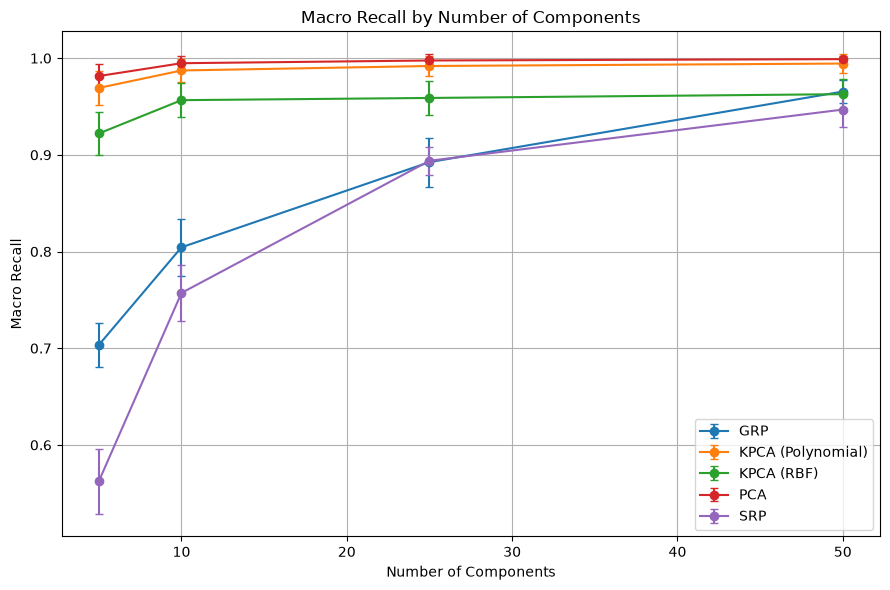

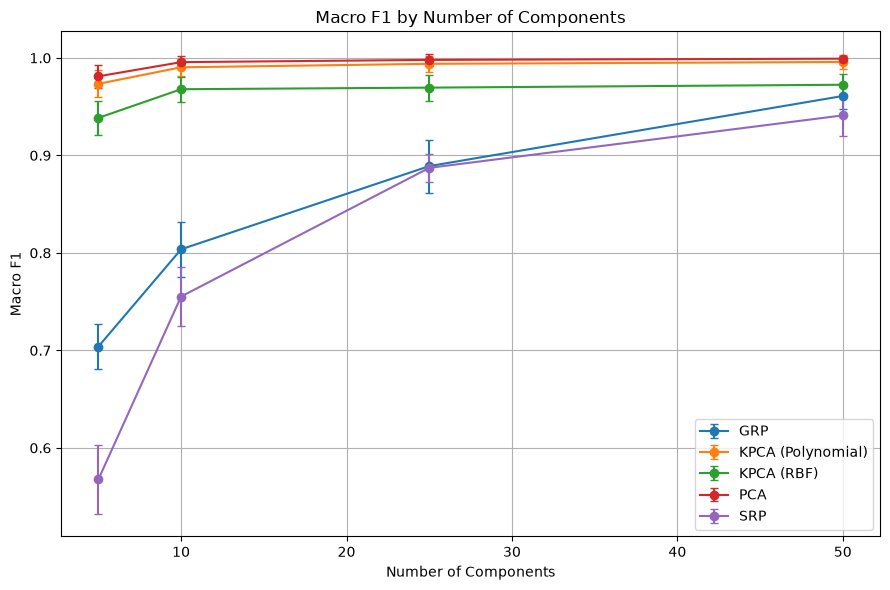

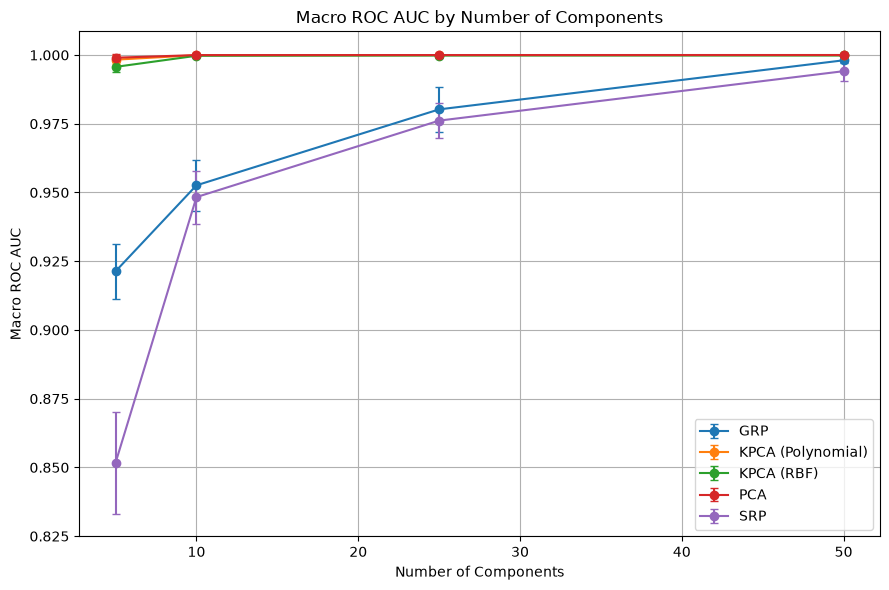

In [8]:
# Plotting function + generate all metric comparison plot

def plot_metric_comparison(master_df, metric_name, save_path=None):
    plt.figure(figsize=(9, 6))
    subset = master_df[master_df["Metric"] == metric_name]
    for method_name, group in subset.groupby("Method"):
        group = group.sort_values("n_components")
        plt.errorbar(
            group["n_components"], group["Mean"], yerr=group["Std"],
            marker="o", capsize=3, label=method_name,
        )
    plt.xlabel("Number of Components")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} by Number of Components")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


for metric in ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Macro ROC AUC"]:
    fname = metric.replace(" ", "_").lower()
    plot_metric_comparison(
        master_classification, metric,
        save_path=comparison_fig_dir / f"comparison_{fname}.png",
    )

In [9]:
# Wide-format pivot tables for every classification metric
classification_metrics = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Macro ROC AUC"]

pivot_tables = {}
for metric in classification_metrics:
    pivot = (
        master_classification[master_classification["Metric"] == metric]
        .pivot(index="n_components", columns="Method", values="Mean")
        .round(4)
    )
    pivot_tables[metric] = pivot

    fname = metric.replace(" ", "_").lower()
    pivot.to_csv(metrics_dir / f"comparison_{fname}_pivot.csv")

# Display all five
for metric, pivot in pivot_tables.items():
    print(f"\n{metric}")
    display(pivot)


Accuracy


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.7286,0.9770,0.9361,0.9838,0.5810
10,0.8037,0.9913,0.9658,0.9958,0.7838
25,0.8939,0.9943,0.9678,0.9985,0.8851
50,0.9620,0.9965,0.9710,0.9995,0.9428



Macro Precision


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.7119,0.9795,0.9608,0.9815,0.5910
10,0.8073,0.9940,0.9819,0.9966,0.7597
25,0.8887,0.9962,0.9826,0.9984,0.8848
50,0.9578,0.9974,0.9843,0.9994,0.9377



Macro Recall


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.7034,0.9692,0.9221,0.9815,0.5624
10,0.8044,0.9873,0.9566,0.9948,0.7572
25,0.8925,0.9919,0.9589,0.9976,0.8939
50,0.9655,0.9944,0.9628,0.9990,0.9468



Macro F1


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.7039,0.9734,0.9385,0.9811,0.5677
10,0.8037,0.9904,0.9679,0.9957,0.7552
25,0.8890,0.9939,0.9695,0.9980,0.8872
50,0.9609,0.9958,0.9725,0.9992,0.9410



Macro ROC AUC


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.9213,0.9983,0.9957,0.999,0.8517
10,0.9526,0.9999,0.9997,1.000,0.9483
25,0.9802,1.0000,0.9998,1.000,0.9761
50,0.9981,1.0000,0.9998,1.000,0.9941


In [10]:
# Combined Mean ± Std pivot, formatted as a single string per cell
combined_pivots = {}
for metric in classification_metrics:
    subset = master_classification[master_classification["Metric"] == metric].copy()
    subset["Formatted"] = subset["Mean"].round(4).astype(str) + " ± " + subset["Std"].round(4).astype(str)
    pivot = subset.pivot(index="n_components", columns="Method", values="Formatted")
    combined_pivots[metric] = pivot

    fname = metric.replace(" ", "_").lower()
    pivot.to_csv(metrics_dir / f"comparison_{fname}_pivot_with_std.csv")

for metric, pivot in combined_pivots.items():
    print(f"\n{metric} (Mean ± Std)")
    display(pivot)


Accuracy (Mean ± Std)


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.7286 ± 0.0231,0.977 ± 0.0114,0.9361 ± 0.0176,0.9838 ± 0.0101,0.581 ± 0.0337
10,0.8037 ± 0.0252,0.9913 ± 0.0072,0.9658 ± 0.0142,0.9958 ± 0.0056,0.7838 ± 0.0243
25,0.8939 ± 0.026,0.9943 ± 0.0067,0.9678 ± 0.0146,0.9985 ± 0.0041,0.8851 ± 0.0152
50,0.962 ± 0.0132,0.9965 ± 0.0057,0.971 ± 0.0126,0.9995 ± 0.0017,0.9428 ± 0.0198



Macro Precision (Mean ± Std)


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.7119 ± 0.027,0.9795 ± 0.0093,0.9608 ± 0.0118,0.9815 ± 0.0113,0.591 ± 0.0419
10,0.8073 ± 0.0282,0.994 ± 0.0054,0.9819 ± 0.0066,0.9966 ± 0.0048,0.7597 ± 0.0339
25,0.8887 ± 0.0307,0.9962 ± 0.0048,0.9826 ± 0.0072,0.9984 ± 0.0051,0.8848 ± 0.0155
50,0.9578 ± 0.0152,0.9974 ± 0.0043,0.9843 ± 0.006,0.9994 ± 0.0019,0.9377 ± 0.0242



Macro Recall (Mean ± Std)


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.7034 ± 0.0232,0.9692 ± 0.0172,0.9221 ± 0.0222,0.9815 ± 0.0129,0.5624 ± 0.0333
10,0.8044 ± 0.0298,0.9873 ± 0.0116,0.9566 ± 0.0176,0.9948 ± 0.0076,0.7572 ± 0.0286
25,0.8925 ± 0.0254,0.9919 ± 0.0107,0.9589 ± 0.0178,0.9976 ± 0.0064,0.8939 ± 0.0146
50,0.9655 ± 0.0117,0.9944 ± 0.0095,0.9628 ± 0.0157,0.999 ± 0.0035,0.9468 ± 0.0183



Macro F1 (Mean ± Std)


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.7039 ± 0.0227,0.9734 ± 0.014,0.9385 ± 0.0178,0.9811 ± 0.0121,0.5677 ± 0.035
10,0.8037 ± 0.0283,0.9904 ± 0.0089,0.9679 ± 0.0129,0.9957 ± 0.0061,0.7552 ± 0.03
25,0.889 ± 0.0272,0.9939 ± 0.008,0.9695 ± 0.0133,0.998 ± 0.0057,0.8872 ± 0.0143
50,0.9609 ± 0.0133,0.9958 ± 0.0072,0.9725 ± 0.0115,0.9992 ± 0.0028,0.941 ± 0.0215



Macro ROC AUC (Mean ± Std)


Method,GRP,KPCA (Polynomial),KPCA (RBF),PCA,SRP
n_components,,,,,
5,0.9213 ± 0.0101,0.9983 ± 0.0016,0.9957 ± 0.0018,0.999 ± 0.0012,0.8517 ± 0.0185
10,0.9526 ± 0.0094,0.9999 ± 0.0001,0.9997 ± 0.0003,1.0 ± 0.0001,0.9483 ± 0.0096
25,0.9802 ± 0.0083,1.0 ± 0.0001,0.9998 ± 0.0003,1.0 ± 0.0,0.9761 ± 0.0063
50,0.9981 ± 0.0011,1.0 ± 0.0,0.9998 ± 0.0002,1.0 ± 0.0,0.9941 ± 0.0034


In [11]:
# Statistical comparison: pairwise Welch's t-tests across methods

n_splits = 25  # 5-fold x 5 repeats, per configuration

def cohens_d_from_stats(mean1, std1, n1, mean2, std2, n2):
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    return (mean1 - mean2) / pooled_std

def pairwise_comparisons(master_df, metric_name, n_components, n=n_splits):
    subset = master_df[
        (master_df["Metric"] == metric_name) & (master_df["n_components"] == n_components)
    ]
    results = []
    for (_, r1), (_, r2) in combinations(subset.iterrows(), 2):
        stat, p = ttest_ind_from_stats(
            r1["Mean"], r1["Std"], n,
            r2["Mean"], r2["Std"], n,
            equal_var=False,
        )
        d = cohens_d_from_stats(r1["Mean"], r1["Std"], n, r2["Mean"], r2["Std"], n)
        results.append({
            "n_components": n_components, "Metric": metric_name,
            "Method A": r1["Method"], "Method B": r2["Method"],
            "Mean A": r1["Mean"], "Mean B": r2["Mean"],
            "t-statistic": stat, "p-value": p, "Cohen's d": d,
        })
    return pd.DataFrame(results)

def holm_bonferroni(pvals, alpha=0.05):
    pvals = np.array(pvals)
    order = np.argsort(pvals)
    m = len(pvals)
    adjusted = np.empty(m)
    prev = 0
    for i, idx in enumerate(order):
        adj_p = max((m - i) * pvals[idx], prev)
        adjusted[idx] = min(adj_p, 1.0)
        prev = adjusted[idx]
    return adjusted, adjusted < alpha

# Run comparisons across all classification metrics, not just Accuracy
all_metric_tests = []
for metric in classification_metrics:
    for nc in n_components_list:
        all_metric_tests.append(pairwise_comparisons(master_classification, metric, nc))

all_tests_df = pd.concat(all_metric_tests, ignore_index=True)

# Holm-Bonferroni correction applied per metric, not globally across all metrics together
adjusted_frames = []
for metric in classification_metrics:
    metric_subset = all_tests_df[all_tests_df["Metric"] == metric].copy()
    adj_p, sig = holm_bonferroni(metric_subset["p-value"])
    metric_subset["p-value (Holm-adjusted)"] = adj_p
    metric_subset["Significant (α=0.05)"] = sig
    adjusted_frames.append(metric_subset)

all_tests_df = pd.concat(adjusted_frames, ignore_index=True)
all_tests_df.to_csv(metrics_dir / "all_metrics_pairwise_significance.csv", index=False)
all_tests_df.sort_values(["Metric", "n_components", "p-value"])

,n_components,Metric,Method A,Method B,Mean A,Mean B,t-statistic,p-value,Cohen's d,p-value (Holm-adjusted),Significant (α=0.05)
5,5,Accuracy,GRP,KPCA (RBF),0.728581,0.936079,-35.697306,1.477383e-34,-10.096723,5.909533e-33,True
7,5,Accuracy,SRP,KPCA (RBF),0.581005,0.936079,-46.708486,6.050116e-34,-13.211155,2.359545e-32,True
6,5,Accuracy,GRP,KPCA (Polynomial),0.728581,0.977022,-48.198963,1.458578e-33,-13.632726,5.542597e-32,True
0,5,Accuracy,PCA,GRP,0.983762,0.728581,50.592311,1.136810e-32,14.309667,4.206198e-31,True
8,5,Accuracy,SRP,KPCA (Polynomial),0.581005,0.977022,-55.688559,2.342057e-31,-15.751103,8.431405e-30,True
...,...,...,...,...,...,...,...,...,...,...,...
119,50,Macro Recall,KPCA (RBF),KPCA (Polynomial),0.962772,0.994433,-8.633872,1.198715e-10,-2.442028,1.438458e-09,True
114,50,Macro Recall,GRP,SRP,0.965467,0.946831,4.291498,1.061337e-04,1.213819,8.490695e-04,True
117,50,Macro Recall,SRP,KPCA (RBF),0.946831,0.962772,-3.311497,1.791777e-03,-0.936633,1.254244e-02,True
113,50,Macro Recall,PCA,KPCA (Polynomial),0.999000,0.994433,2.249885,3.189366e-02,0.636364,1.107767e-01,False


## 4. Computational Efficiency Comparison

Fit time, transform time, and total runtime are compared across methods. Fit time is
shown on a log scale given the substantial difference in cost between KPCA (kernel matrix
computation) and the linear/random-projection methods.

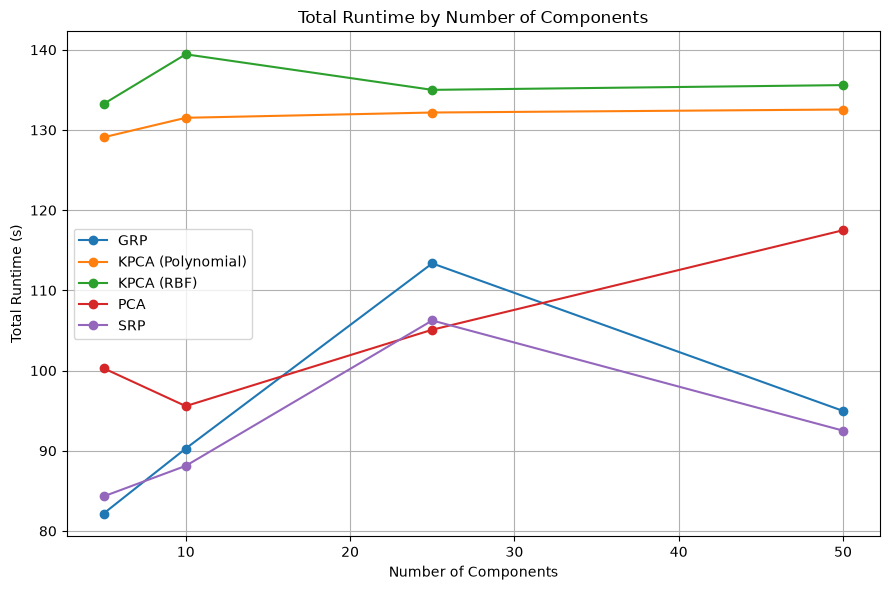

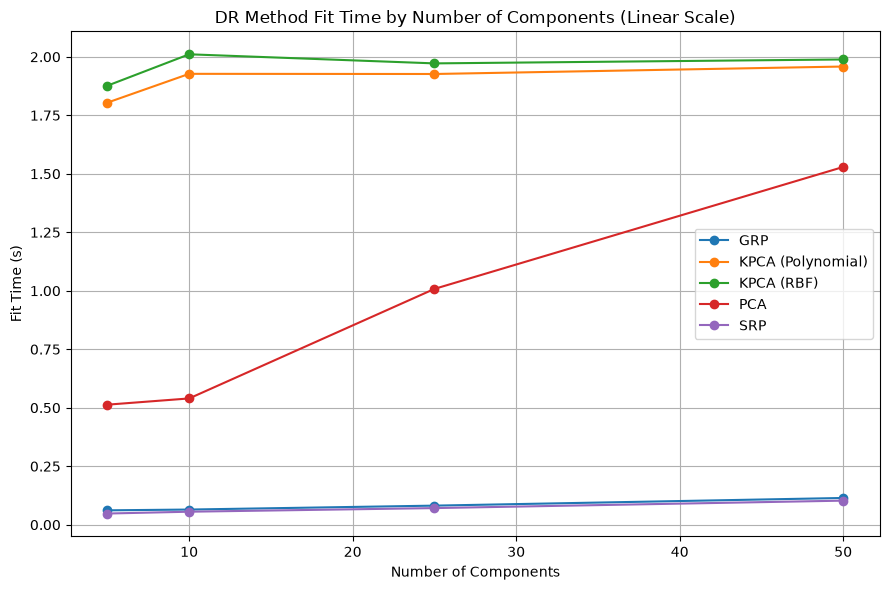

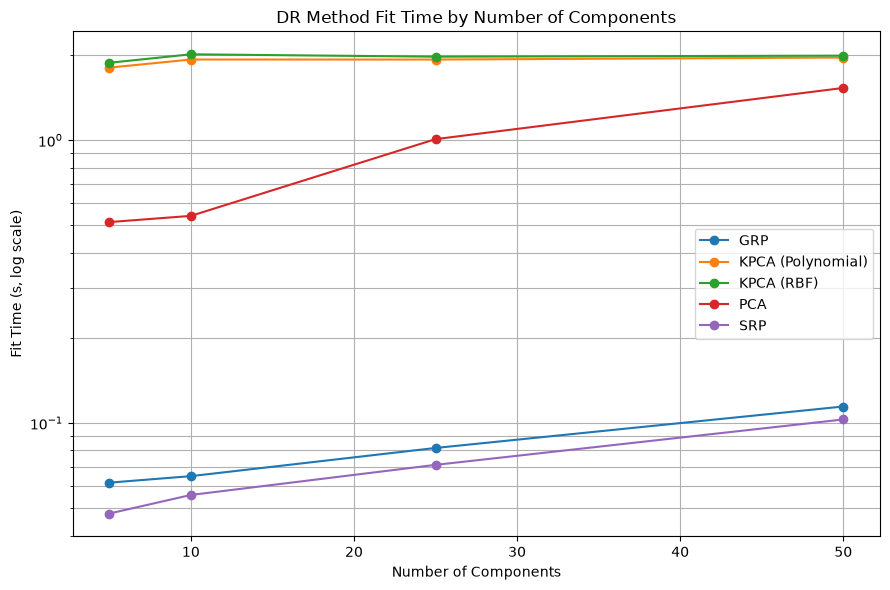

In [12]:
# Total runtime
plt.figure(figsize=(9, 6))
for method_name, group in master_runtime.groupby("Method"):
    group = group.sort_values("n_components")
    plt.plot(group["n_components"], group["Total Runtime (s)"], marker="o", label=method_name)
plt.xlabel("Number of Components")
plt.ylabel("Total Runtime (s)")
plt.title("Total Runtime by Number of Components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(comparison_fig_dir / "comparison_total_runtime.png", dpi=300, bbox_inches="tight")
plt.show()

# Fit time (linear scale, for absolute comparison)
plt.figure(figsize=(9, 6))
for method_name, group in master_runtime.groupby("Method"):
    group = group.sort_values("n_components")
    plt.plot(group["n_components"], group["Fit Time Mean (s)"], marker="o", label=method_name)
plt.xlabel("Number of Components")
plt.ylabel("Fit Time (s)")
plt.title("DR Method Fit Time by Number of Components (Linear Scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(comparison_fig_dir / "comparison_fit_time_linear.png", dpi=300, bbox_inches="tight")
plt.show()

# Fit time (log scale)
plt.figure(figsize=(9, 6))
for method_name, group in master_runtime.groupby("Method"):
    group = group.sort_values("n_components")
    plt.plot(group["n_components"], group["Fit Time Mean (s)"], marker="o", label=method_name)
plt.xlabel("Number of Components")
plt.ylabel("Fit Time (s, log scale)")
plt.yscale("log")
plt.title("DR Method Fit Time by Number of Components")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(comparison_fig_dir / "comparison_fit_time.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Reconstruction Error Comparison

**Note:** reconstruction is computed differently across methods: PCA uses its exact
inverse transform, KPCA uses the approximate pre-image method, and GRP/SRP use the
Moore-Penrose pseudo-inverse of the projection matrix. As stated in Chapter 4, these
values are therefore interpreted within the context of each method rather than as
directly equivalent measures, even though they are plotted together here for visual
comparison.

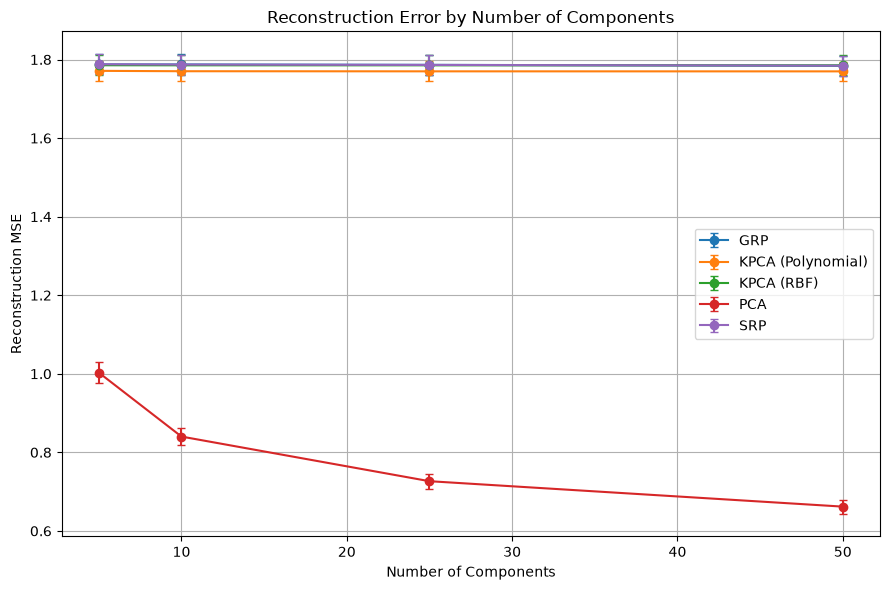

In [13]:
# Reconstruction Plot

plt.figure(figsize=(9, 6))
for method_name, group in master_reconstruction.groupby("Method"):
    group = group.sort_values("n_components")
    plt.errorbar(
        group["n_components"], group["Mean"], yerr=group["Std"],
        marker="o", capsize=3, label=method_name,
    )
plt.xlabel("Number of Components")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction Error by Number of Components")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(comparison_fig_dir / "comparison_reconstruction_mse.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Representation Quality (Reported Separately per Method)

Consistent with Chapter 4, representation quality is reported descriptively per method
rather than combined into a single plot, since each measure captures a different
property of the reduced feature space. The exception is GRP and SRP, which are compared
directly since both are evaluated using the same measure (pairwise distance correlation).

In [14]:
# PCA: explained variance at reported component counts

pca_var_df = pd.read_csv(metrics_dir / "PCA_explained_variance.csv")
pca_repr_summary = pca_var_df[
    pca_var_df["Principal Component"].isin(n_components_list)
][["Principal Component", "Cumulative Explained Variance"]].rename(
    columns={"Principal Component": "n_components"}
)
pca_repr_summary

,n_components,Cumulative Explained Variance
4,5,0.362987
9,10,0.465855
24,25,0.559722
49,50,0.636982


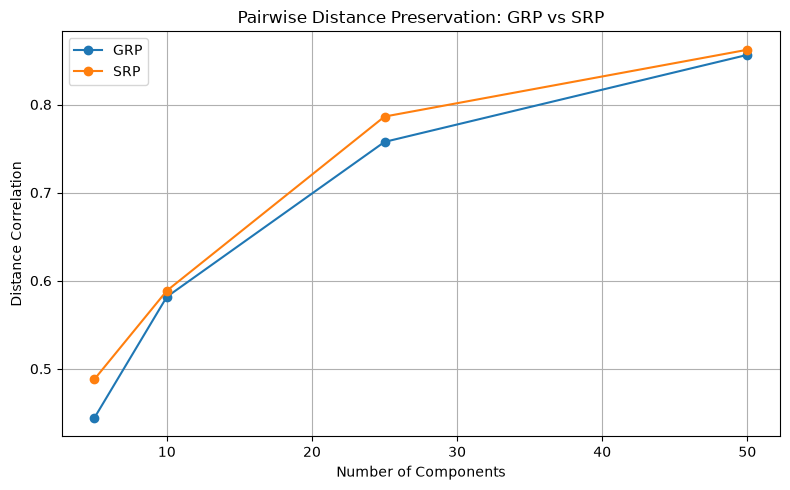

Method,GRP,SRP
n_components,,
5,0.444087,0.487961
10,0.581715,0.588652
25,0.757538,0.786298
50,0.856329,0.862146


In [15]:
# GRP vs SRP: distance preservation (shared metric, safe to combine)

grp_dist = pd.read_csv(metrics_dir / "grp_distance_preservation.csv")
grp_dist["Method"] = "GRP"
srp_dist = pd.read_csv(metrics_dir / "srp_distance_preservation.csv")
srp_dist["Method"] = "SRP"
distance_df = pd.concat([grp_dist, srp_dist], ignore_index=True)

plt.figure(figsize=(8, 5))
for method_name, group in distance_df.groupby("Method"):
    group = group.sort_values("n_components")
    plt.plot(group["n_components"], group["Distance Correlation"], marker="o", label=method_name)
plt.xlabel("Number of Components")
plt.ylabel("Distance Correlation")
plt.title("Pairwise Distance Preservation: GRP vs SRP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(comparison_fig_dir / "comparison_distance_preservation_grp_srp.png", dpi=300, bbox_inches="tight")
plt.show()

distance_df.pivot(index="n_components", columns="Method", values="Distance Correlation")

In [16]:
## KPCA: silhouette by components

kpca_silhouette_df = pd.read_csv(metrics_dir / "KPCA_silhouette_by_components.csv")
kpca_silhouette_df.pivot(index="n_components", columns="Kernel", values="Silhouette Score")

Kernel,Polynomial,RBF
n_components,,
5,0.404880,0.379140
10,0.342880,0.312136
25,0.270812,0.223151
50,0.229727,0.182150


## 7. Best configuration per method

In [17]:
best_configs = (
    master_classification[master_classification["Metric"] == "Accuracy"]
    .sort_values("Mean", ascending=False)
    .groupby("Method")
    .first()
    .reset_index()[["Method", "n_components", "Mean", "Std"]]
    .rename(columns={"Mean": "Best Accuracy", "Std": "Accuracy Std"})
    .sort_values("Best Accuracy", ascending=False)
)
best_configs.to_csv(metrics_dir / "best_configuration_per_method.csv", index=False)
best_configs

,Method,n_components,Best Accuracy,Accuracy Std
3,PCA,50,0.999500,0.001731
1,KPCA (Polynomial),50,0.996502,0.005727
2,KPCA (RBF),50,0.971028,0.012622
0,GRP,50,0.962042,0.013248
4,SRP,50,0.942823,0.019804
